In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [ ]:
import math
import keyring
import itertools

In [5]:
# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [6]:
# read in the data
# df = pd.read_csv(data_dir + "/data_processed/tbi_merged.csv")
df = pd.read_csv("../../data_processing/tbi_cleaned.csv")
df

C:\Users\yianz\AppData\Local\Temp\ipykernel_21280\2582001599.py:3: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data_processing/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455179,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
455180,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
455181,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
455182,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [148]:
car = gpd.read_file(data_dir + "/Data_Processed/car_trips.gpkg")
bike = gpd.read_file(data_dir + "/Data_Processed/bike_trips.gpkg")
# transit = gpd.read_file(data_dir + "/Data_Processed/transit_trips.gpkg")
# walk = gpd.read_file(data_dir + "/Data_Processed/walk_trips.gpkg")

In [69]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

In [8]:
## duration analysis

In [114]:
## overall summary statistics
df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    455184.000000
mean         19.273859
std          22.771212
min           0.100000
25%           8.250000
50%          13.983333
75%          23.033333
95%          49.700000
max         970.516667
Name: duration, dtype: float64

(0.0, 200.0)

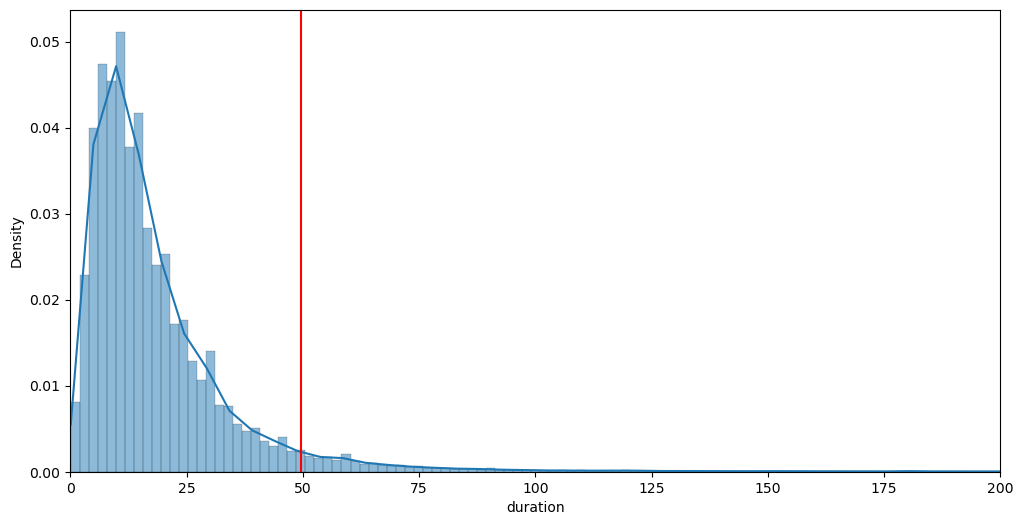

In [70]:
# overall distribution of duration
# there are repetitive peaks, likely since the temporal resolution is discrete with respect ot minutes
fig, ax = plot_density(df["duration"], bins=500)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read

Text(0.5, 0, 'log duration')

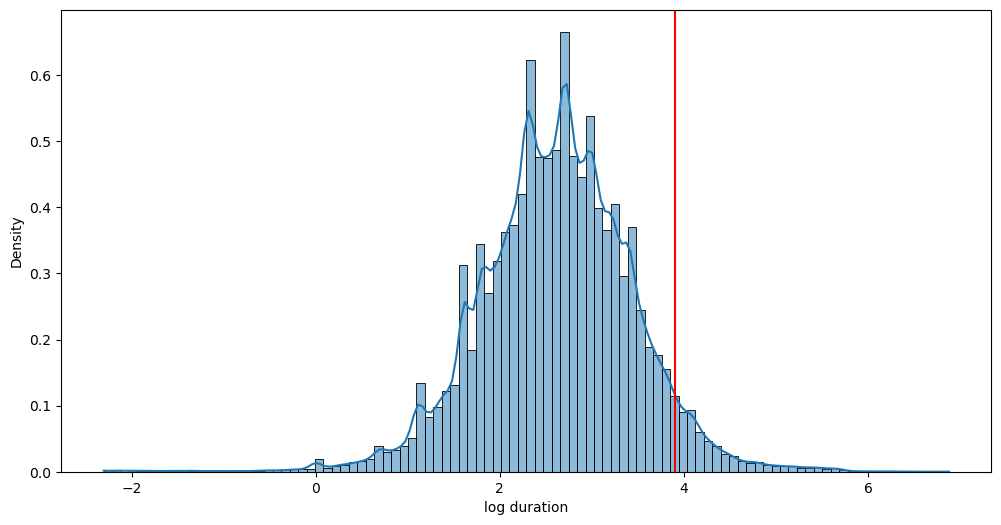

In [115]:
# overall distribution of the log of duration
fig, ax = plot_density(np.log(df["duration"]), bins=100)
ax.set_xlabel("log duration")

In [ ]:
## duration analysis segmented by mode

In [116]:
df["mode"].value_counts()

Car                       380543
Walk                       50134
Transit                    11279
Bike/Scooter                7705
School bus                  3668
Taxi/Ridehail/Carshare      1855
Name: mode, dtype: int64

In [53]:
# currently ignore schools bus and taxi/ridehail/carshare -- can decide whether to omit or group with others later
# with school buses, we might need analysis for school-age children only since school buses aren't a widely available mode to the public
# with taxi/ridehail/carshare, could be transit but it is very distinct, possibly omit or add as another option
df_mode_cleaned = df[~df["mode"].isin(["School bus", "Taxi/Ridehail/Carshare"])]

In [107]:
palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
def plot_mode_density(df: pd.DataFrame, key: str, percentile=0.95, size=(12, 6), bins=300):
    fig, ax = plt.subplots(figsize=size)
    for mode in df["mode"].value_counts().index: # cycle through all modes
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(group[key], ax=ax, stat="density", kde=True, label=mode, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = group[key].quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot
    return fig, ax

In [129]:
def show_summaries(df: pd.DataFrame, key: str, percentile=0.95): # show normal summaries for each mode side by side
    res = []
    p = [0.25, 0.5, 0.75]
    p.append(percentile)
    for mode in df["mode"].value_counts().index:
        group = df[df["mode"] == mode]
        res.append(group[key].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = df["mode"].value_counts().index
    return x

In [130]:
show_summaries(df_mode_cleaned, "duration")

,Car,Walk,Transit,Bike/Scooter
count,380543.000000,50134.000000,11279.000000,7705.000000
mean,18.915816,16.149813,38.154242,23.640117
std,22.354501,18.693085,29.783879,25.802185
min,0.100000,0.100000,0.133333,0.133333
25%,8.350000,6.433333,20.000000,9.000000
50%,13.883333,11.450000,32.033333,16.083333
75%,22.533333,19.466667,48.391667,29.050000
95%,47.250000,42.200000,85.260000,66.286667
max,970.516667,325.466667,570.000000,325.800000


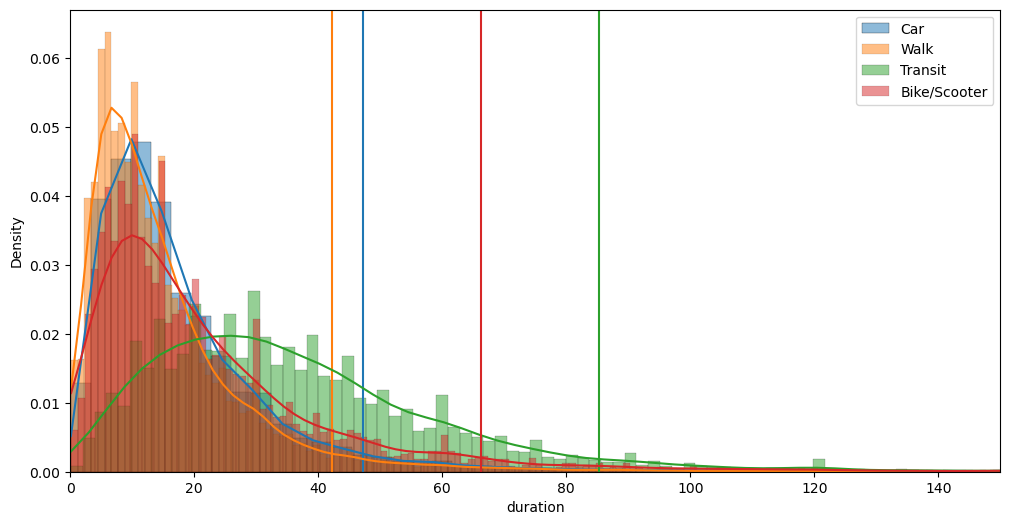

In [106]:
# plot of densities of all modes overlayed on top of one another
fig, ax = plot_mode_density(df_mode_cleaned, "duration")
ax.set_xlim(left=0, right=150)
plt.legend()

In [ ]:
## difference between driving and non-driving mode durations

In [ ]:
# bike vs car

In [193]:
# for each bike trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these bikers tradeoff between car & bike duration
bike_minus_car_duration = df[df["mode"] == "Bike/Scooter"]["duration"] - (car.set_index("trip_id").loc[df[(df["mode"] == "Bike/Scooter")]["trip_id"].values].duration_seconds / 60).values

In [194]:
# not sure if it would be feasible to switch to bike if car is 53 minutes faster
# self sampling likely plays a role -- maybe adopt a smaller percentile to adjust?
bike_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    7705.000000
mean       16.805448
std        23.208526
min       -11.326667
25%         5.136667
50%        10.326667
75%        19.445000
95%        53.201667
max       303.550000
Name: duration, dtype: float64

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='duration', ylabel='Density'>)

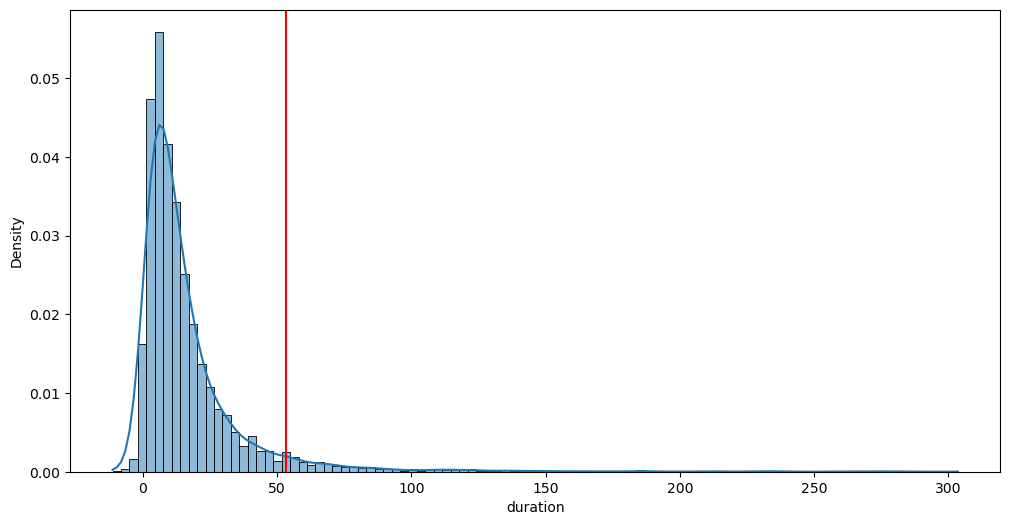

In [195]:
plot_density(bike_minus_car_duration)